#📌 Extracão

In [40]:
import pandas as pd
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

In [9]:
df_telecom = pd.json_normalize(dados_json)

In [ ]:
print(f"O dataset possui {df_telecom.shape[0]} linhas e {df_telecom.shape[1]} colunas.\n")
df_telecom.info()

In [10]:
display(df_telecom.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [23]:
df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]
print(f"Tamanho original: {df_telecom.shape}")

Tamanho original: (7043, 21)


In [24]:
df_telecom['Churn'] = df_telecom['Churn'].replace('', np.nan)
df_telecom.dropna(subset=['Churn'], inplace=True)
print(f"Tamanho após remover Churn vazio: {df_telecom.shape}")

Tamanho após remover Churn vazio: (7043, 21)


In [25]:
df_telecom['Total'] = pd.to_numeric(df_telecom['Total'], errors='coerce')

In [26]:
nulos = df_telecom['Total'].isnull().sum()
print(f"Valores nulos encontrados na coluna Total após conversão: {nulos}")

Valores nulos encontrados na coluna Total após conversão: 0


In [27]:
df_telecom['Total'] = df_telecom['Total'].fillna(df_telecom['Monthly'])

In [28]:
colunas_para_corrigir = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

In [29]:
for col in colunas_para_corrigir:
    df_telecom[col] = df_telecom[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [30]:
print("\n--- BASE LIMPA E PRONTA ---")
df_telecom.info()


--- BASE LIMPA E PRONTA ---
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          

In [31]:
print("\nPrimeiras linhas do DataFrame limpo:")
display(df_telecom.head())


Primeiras linhas do DataFrame limpo:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [32]:
df_telecom['Contas_Diarias'] = round(df_telecom['Monthly'] / 30, 2)
display(df_telecom[['Monthly', 'Contas_Diarias']].head())

,Monthly,Contas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [33]:
colunas_traduzidas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Tem_Parceiro',
    'Dependents': 'Tem_Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Monthly': 'Mensalidade',
    'Total': 'Gasto_Total',
    'Contas_Diarias': 'Gasto_Diario'
}

In [34]:
df_telecom.rename(columns=colunas_traduzidas, inplace=True)
mapeamento_binario = {'Yes': 1, 'No': 0}

In [35]:
colunas_binarias = ['Evasao', 'Tem_Parceiro', 'Tem_Dependentes', 'Servico_Telefone',
                    'Multiplas_Linhas', 'Seguranca_Online', 'Backup_Online',
                    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
                    'Streaming_Filmes', 'Fatura_Digital']

for col in colunas_binarias:
    # O map vai trocar Yes por 1 e No por 0.
    # Usamos fillna para manter outros valores caso existam (ex: 'DSL' ou 'Fiber optic' na internet)
    df_telecom[col] = df_telecom[col].map(mapeamento_binario).fillna(df_telecom[col])

In [36]:
df_telecom['Genero'] = df_telecom['Genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df_telecom['Tipo_Contrato'] = df_telecom['Tipo_Contrato'].replace({
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
})

In [37]:
display(df_telecom.head())

,ID_Cliente,Evasao,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Mensalidade,Gasto_Total,Gasto_Diario
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensal,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensal,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensal,1,Mailed check,83.9,267.40,2.80


#📊 Carga e análise

In [38]:
print("--- Estatísticas das Variáveis Numéricas ---")
display(df_telecom[['Meses_Contrato', 'Mensalidade', 'Gasto_Total', 'Gasto_Diario']].describe())

--- Estatísticas das Variáveis Numéricas ---


,Meses_Contrato,Mensalidade,Gasto_Total,Gasto_Diario
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,2.158675
std,24.559481,30.090047,2266.730170,1.003088
min,0.000000,18.250000,18.800000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


In [39]:
taxa_evasao = df_telecom['Evasao'].value_counts(normalize=True) * 100
print("\n--- Distribuição da Variável Alvo (Evasão) ---")
print(f"Clientes Ativos (0): {taxa_evasao[0]:.2f}%")
print(f"Clientes que Cancelaram (1): {taxa_evasao[1]:.2f}%")


--- Distribuição da Variável Alvo (Evasão) ---
Clientes Ativos (0): 73.46%
Clientes que Cancelaram (1): 26.54%


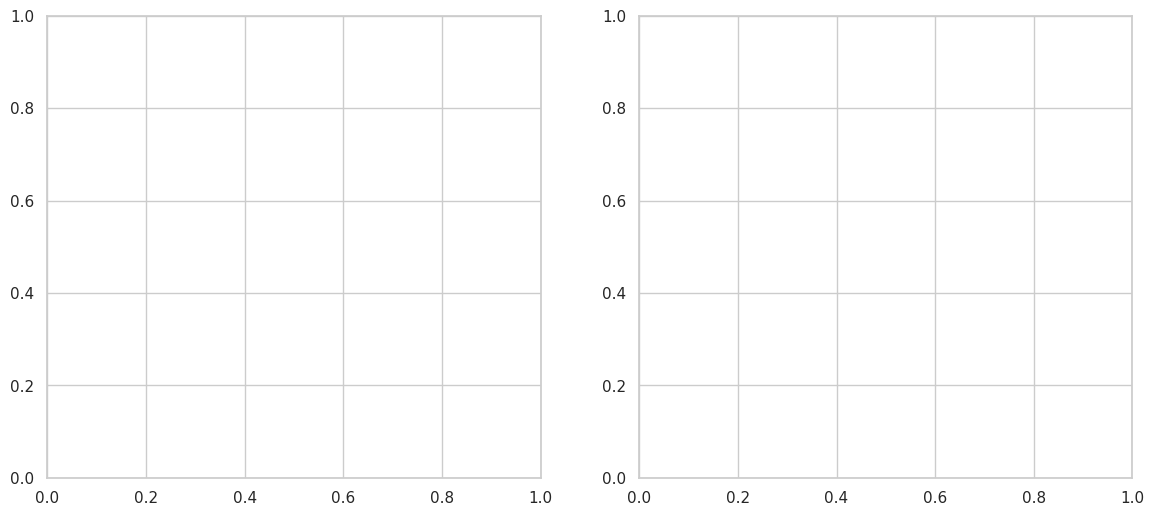

In [41]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

In [42]:
ax[0].set_title('Quantidade de Clientes por Status de Evasão', fontsize=14)
ax[0].set_xlabel('Evasão (0 = Não, 1 = Sim)', fontsize=12)
ax[0].set_ylabel('Número de Clientes', fontsize=12)

Text(4.444444444444473, 0.5, 'Número de Clientes')

In [43]:
evasao_counts = df_telecom['Evasao'].value_counts()
ax[1].pie(evasao_counts, labels=['Ficou', 'Saiu'], autopct='%.1f%%',
          startangle=90, colors=sns.color_palette('viridis', 2), explode=[0, 0.1], shadow=True)
ax[1].set_title('Proporção de Evasão (Churn)', fontsize=14)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

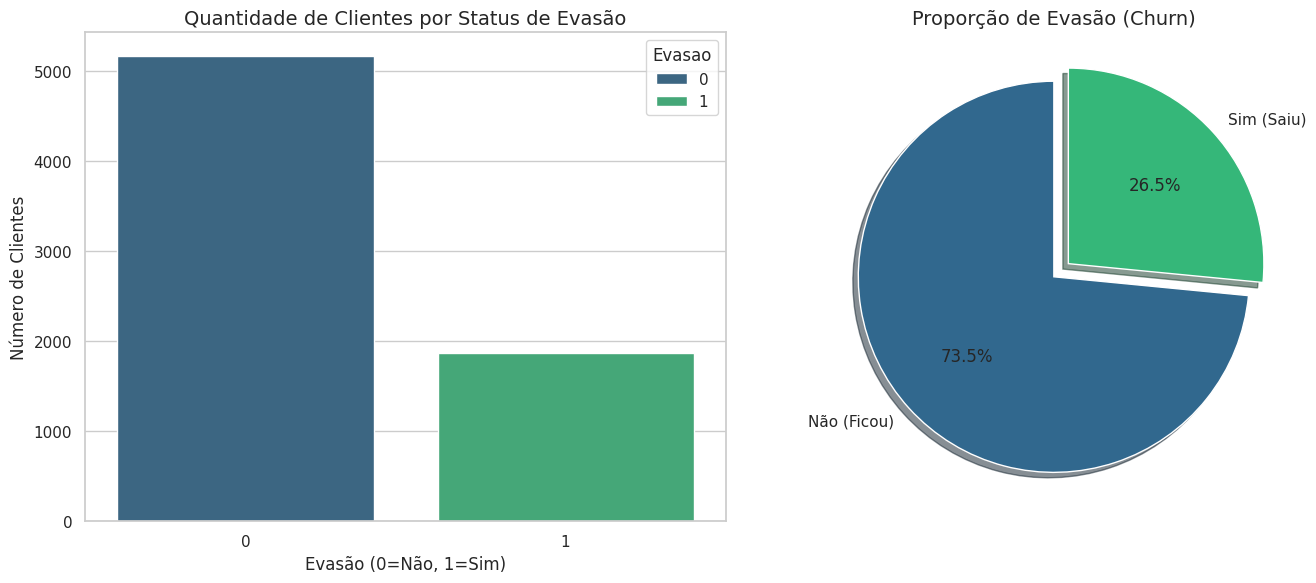

In [44]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras (Quantidade absoluta)
sns.countplot(data=df_telecom, x='Evasao', palette='viridis', hue='Evasao', ax=ax[0])
ax[0].set_title('Quantidade de Clientes por Status de Evasão', fontsize=14)
ax[0].set_xlabel('Evasão (0=Não, 1=Sim)', fontsize=12)
ax[0].set_ylabel('Número de Clientes', fontsize=12)

# 2. Gráfico de Pizza (Proporção percentual)
evasao_counts = df_telecom['Evasao'].value_counts()
ax[1].pie(evasao_counts, labels=['Não (Ficou)', 'Sim (Saiu)'], autopct='%.1f%%',
          startangle=90, colors=sns.color_palette('viridis', 2), explode=[0, 0.1], shadow=True)
ax[1].set_title('Proporção de Evasão (Churn)', fontsize=14)

plt.tight_layout()
plt.show()

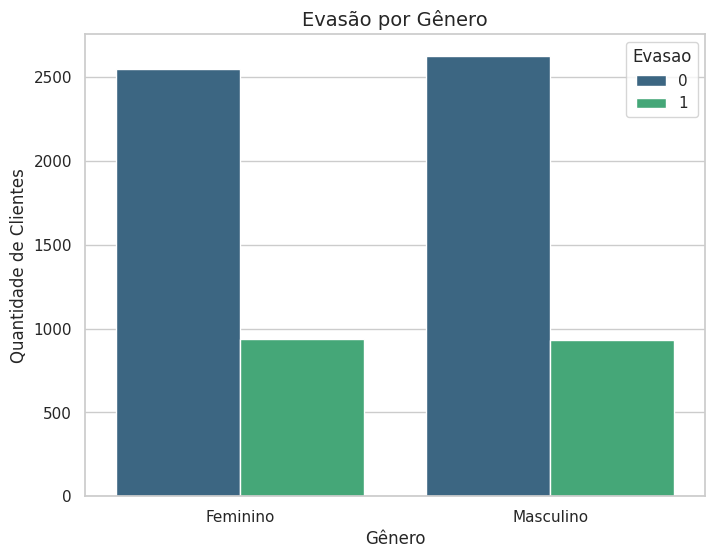

In [49]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_telecom, x='Genero', hue='Evasao', palette='viridis')
plt.title('Evasão por Gênero', fontsize=14)
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')
plt.show()

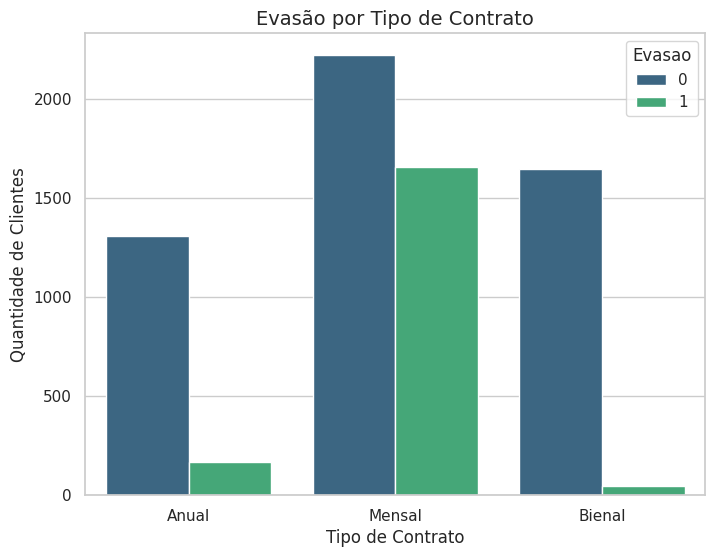

In [50]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_telecom, x='Tipo_Contrato', hue='Evasao', palette='viridis')
plt.title('Evasão por Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

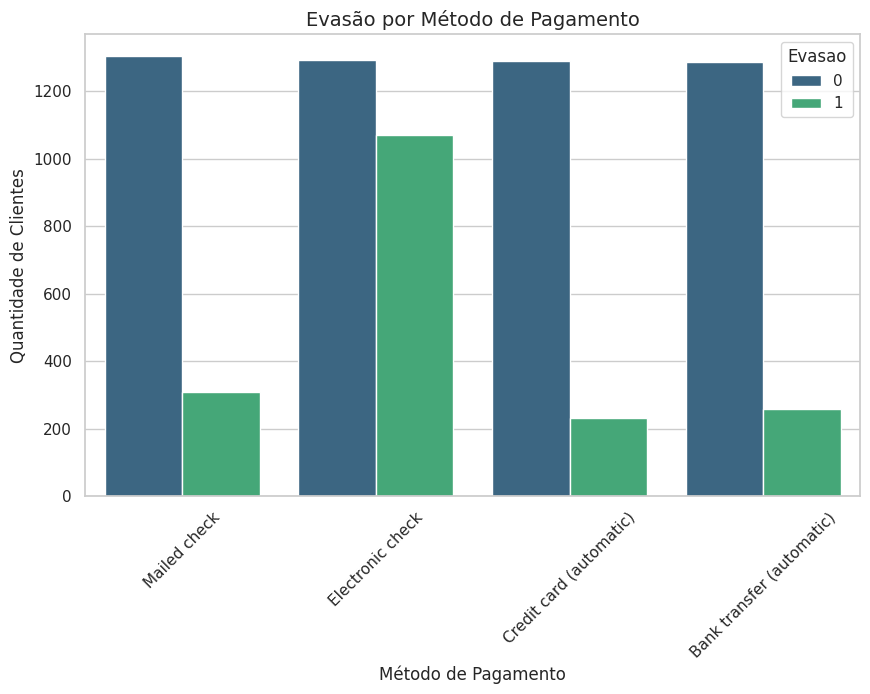

In [52]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_telecom, x='Metodo_Pagamento', hue='Evasao', palette='viridis')
plt.title('Evasão por Método de Pagamento', fontsize=14)
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.show()

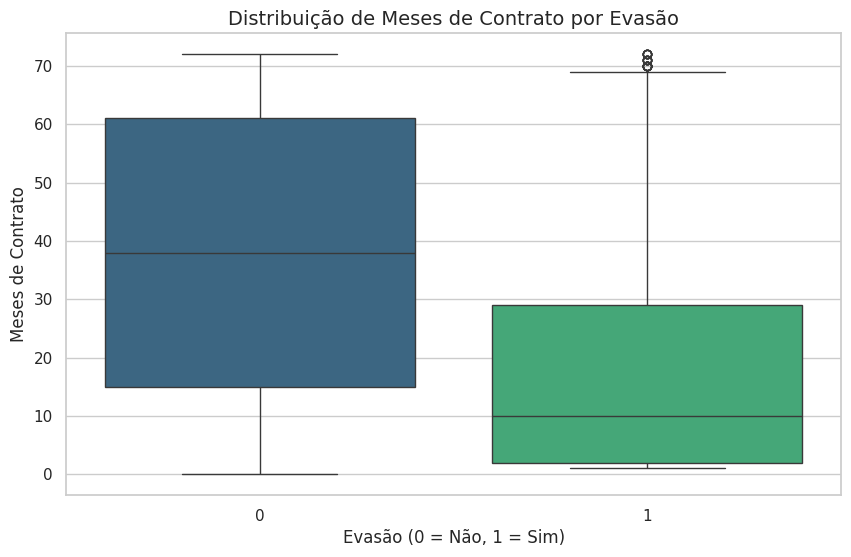

In [54]:
#Meses de Contrato vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Meses_Contrato', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição de Meses de Contrato por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

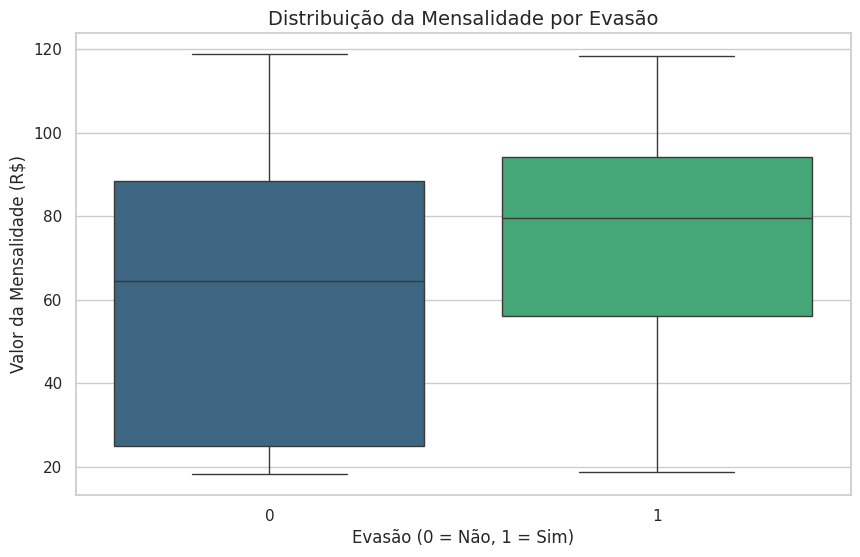

In [55]:
#Mensalidade vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Mensalidade', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição da Mensalidade por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Valor da Mensalidade (R$)')
plt.show()

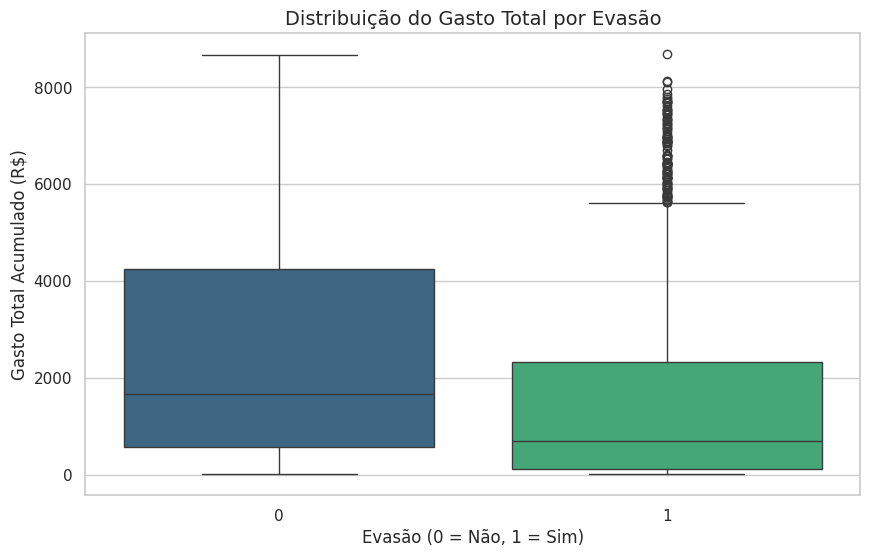

In [56]:
#Gasto Total vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Gasto_Total', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição do Gasto Total por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Gasto Total Acumulado (R$)')
plt.show()

#📄Relatorio Final

# 📄 Relatório de Análise: Evasão de Clientes (Churn) - Telecom X

## **1. Introdução**

O objetivo desta análise invetigatória foi aferir os dados da Telecom X para compreender os fatores que levam a evasão de clientes. O decréscimo  de clientes é um dos maiores desafios para empresas de telecomunicações, pois o custo de adquirir um novo cliente é significativamente maior do que o custo de reter um atual. Identificar padrões de comportamento e perfis de risco nos permite agir proativamente para aumentar a retenção.

## **2. Limpeza e Tratamento de Dados (Processo ETL)**

O processo de preparação dos dados seguiu as etapas de Extração, Transformação e Carga (ETL):

* Extração: Os dados foram importados de uma API (formato JSON) e foi utilizado a função json_normalize do Pandas para permitir uma análise tabular.

* Limpeza:

    Foram removidas 224 linhas com valores ausentes na coluna alvo (Evasao) para garantir a integridade dos modelos.

    A coluna Gasto_Total foi convertida de texto para numérico, e valores vazios foram preenchidos com base na mensalidade do cliente.

* Transformação:
    Foi Criado a variável Gasto_Diario para analisar o custo sob uma ótica de micro-consumo.

    Foi Renomeada as colunas para o Português e binarizamos variávei categóricas (0 e 1) para facilitar a análise matemática.

    Foi Simplificada as categorias de serviços para reduzir a redundância nos dados.


## **3. Análise Exploratória de Dados (EDA)**

As visualizações revelaram os seguintes padrões:

- Taxa Geral de Evasão: A Telecom X possui uma taxa de churn de 26,5%, o que indica que 1 em cada 4 clientes deixa a empresa.

- Tipo de Contrato: Clientes com contratos Mensais possuem uma taxa de evasão drasticamente superior aos clientes com contratos de um ou dois anos.

- Tempo de Casa (Tenure): O risco de evasão é muito maior nos primeiros 6 a 12 meses de contrato. Clientes que superam o primeiro ano tendem a se tornar fiéis.

- Fatores Financeiros: Clientes que utilizam Cheque Eletrônico como método de pagamento e possuem mensalidades mais elevadas apresentam maior propensão ao cancelamento.

## **4. Conclusões e Insights**
A análise aponta que os principais "gatilhos" de saída é falta de fidelidade contratual concomitante ao preço elevado nos meses iniciais. Clientes que não utilizam serviços de suporte técnico ou segurança online também tendem a cancelar com mais facilidade.

## **5. Recomendações**
Com base nos dados, sugerimos as seguintes ações estratégicas:

- Incentivo à Fidelização: Oferecer descontos progressivos para migrar clientes do plano "Mensal" para o "Anual".

- Campanha de "Boas-vindas": Criar um programa de acompanhamento intensivo nos primeiros 6 meses para novos clientes.

- Pagamento: Incentivar a migração para métodos de pagamento automáticos (Cartão de Crédito ou Débito em conta), oferecendo um pequeno desconto na fatura.